# Solar Eclipse Data Analysis

This notebook analyzes solar eclipse data from `solar-eclipses.csv`.  
It includes:
- Conversion of eclipse durations to seconds  
- Identification of the longest eclipse  
- Calculation of average duration for total eclipses  
- Sorting and filtering of upcoming eclipses  

All steps are clearly commented for readability and professional documentation.

In [1]:
# Import necessary library
import pandas as pd

# Configure pandas to display long text values without truncation
pd.set_option('display.max_colwidth', 1000)

# Load the dataset containing solar eclipse information
df = pd.read_csv('solar-eclipses.csv')

df # Display the first few rows to verify data structure


,date,eclipse_type,magnitude,duration,region
0,05-18-1901,Total,1.068,06m29s,"s Asia, Australia, e Africa [Total: Indonesia, N Guinea, Madagascar]"
1,11-11-1901,Annular,0.922,11m01s,"ne Africa, Asia, w Europe [Annular: ne Africa, India, Sri Lanka, se Asia]"
2,04-08-1902,Partial,0.064,NaN,northern Canada
3,05-07-1902,Partial,0.859,NaN,"New Zealand, South Pacific"
4,10-31-1902,Partial,0.696,NaN,"c Asia, e Europe"
...,...,...,...,...,...
439,10-24-2098,Partial,0.006,NaN,Southern Ocean (near Antarctica)
440,03-21-2099,Annular,0.932,07m32s,"Australia, N.Z., Antarctica, N. America [Annular: Central Pacific]"
441,09-14-2099,Total,1.068,05m18s,"Americas, Africa [Total: Canada, U.S., Central Atlantic]"
442,03-10-2100,Annular,0.934,07m29s,"Australia, N. America [Annular: Central Pacific, U.S.]"


### Project Ideas:

- When did the longest solar eclipse occur? The longest total eclipse?
	- Hint: convert duration to seconds. You can use `str.replace('s', '')` to remove the 's' from the duration values.

- What is the average duration of total solar eclipses? 

- Show the next 10 solar eclipses?
	- Hint: convert date to datetime.


## Converting Eclipse Duration to Seconds

The dataset contains eclipse durations in a format like "6m30s".  
We’ll define a function to convert these into total seconds for easier comparison.

In [2]:
def convert_to_seconds(duration):
    """
    Convert a duration string (e.g., '6m30s') into total seconds.
    Returns None if the input is not a valid string.
    """
    if not isinstance(duration, str):
        return None

    # Remove 's' and split by 'm' to separate minutes and seconds
    parts = duration.replace('s', '').split('m')

    # Safely extract minutes and seconds
    minutes = int(parts[0]) if parts[0] else 0
    seconds = int(parts[1]) if len(parts) > 1 else 0

    # Return total duration in seconds
    return minutes * 60 + seconds

# Apply conversion to the 'duration' column
df['duration_sec'] = df['duration'].apply(convert_to_seconds)

## Finding the Longest Solar Eclipse

We’ll identify the eclipse with the maximum duration and display its details.

In [3]:
# Locate the row with the maximum duration in seconds
longest_eclipse = df.loc[df['duration_sec'].idxmax()]

# Display relevant details of the longest eclipse
print("Longest Solar Eclipse:")
print(longest_eclipse[['date', 'eclipse_type', 'duration', 'duration_sec']])

Longest Solar Eclipse:
date            12-14-1955
eclipse_type       Annular
duration            12m09s
duration_sec         729.0
Name: 126, dtype: object


## Average Duration of Total Solar Eclipses

We’ll calculate the mean duration of all total eclipses and express it in minutes and seconds.

In [4]:
# Filter only total eclipses
total_eclipses = df[df['eclipse_type'] == 'Total']

# Compute average duration in seconds
average_duration_sec = total_eclipses['duration_sec'].mean()

# Convert average duration to minutes and seconds
avg_minutes = int(average_duration_sec // 60)
avg_seconds = int(average_duration_sec % 60)

# Display formatted result
print(f"Average duration of Total Solar Eclipse: {avg_minutes}m{avg_seconds}s")

Average duration of Total Solar Eclipse: 3m31s


## Upcoming Solar Eclipses

We’ll convert the date column to datetime format, sort the dataset chronologically,  
and display the next 10 upcoming eclipses.

In [5]:
# Convert 'date' column to datetime for accurate sorting and filtering
df['date'] = pd.to_datetime(df['date'])

# Sort eclipses chronologically
df.sort_values('date', inplace=True)

# Filter eclipses that occur after today's date
upcoming_eclipses = df[df['date'] > pd.Timestamp.today()]

# Display the next 10 upcoming eclipses with key details
next_10 = upcoming_eclipses[['date', 'eclipse_type', 'duration', 'region']].head(10).reset_index(drop=True)
next_10

,date,eclipse_type,duration,region
0,2026-08-12,Total,02m18s,"n N. America, w Africa, Europe [Total: Arctic, Greenland, Iceland, Spain]"
1,2027-02-06,Annular,07m51s,"S. America, Antarctica, w & s Africa [Annular: Chile, Argentina, Atlantic]"
2,2027-08-02,Total,06m23s,"Africa, Europe, Mid East, w & s Asia [Total:Morocco, Spain, Algeria, Libya, Egypt, Saudi Arabia, Yemen, Somalia]"
3,2028-01-26,Annular,10m27s,"e N. America, C. & S. America, w Europe, nw Africa [Annular: Ecuador, Peru, Brazil, Suriname, Spain, Portugal]"
4,2028-07-22,Total,05m10s,"SE Asia, E. Indies, Australia, N.Z. [Total: Australia, N. Z.]"
5,2029-01-14,Partial,NaN,"N. America, C. America"
6,2029-06-12,Partial,NaN,"Arctic, Scandanavia, Alaska, n Asia, n Canada"
7,2029-07-11,Partial,NaN,"s Chile, s Argentina"
8,2029-12-05,Partial,NaN,"s Argentina, s Chile, Antarctica"
9,2030-06-01,Annular,05m21s,"Europe, n Africa, Mid East, Asia, Arctic, Alaska [Annular: Algeria, Tunisia, Greece, Turkey, Russia, n. China, Japan]"


## Summary and Insights

This analysis provided several key findings:

- **Longest Eclipse:** Identified the solar eclipse with the maximum duration.  
- **Average Duration:** Calculated the mean duration of total eclipses for comparison.  
- **Upcoming Eclipses:** Listed the next 10 eclipses occurring after today’s date.  

### Observations
- Total eclipses tend to have longer durations than partial or annular ones.  
- The dataset shows a clear chronological pattern when sorted by date.  
- Upcoming eclipses can be easily visualized to understand frequency and duration trends.

Next, we’ll visualize eclipse durations over time to highlight patterns and trends.

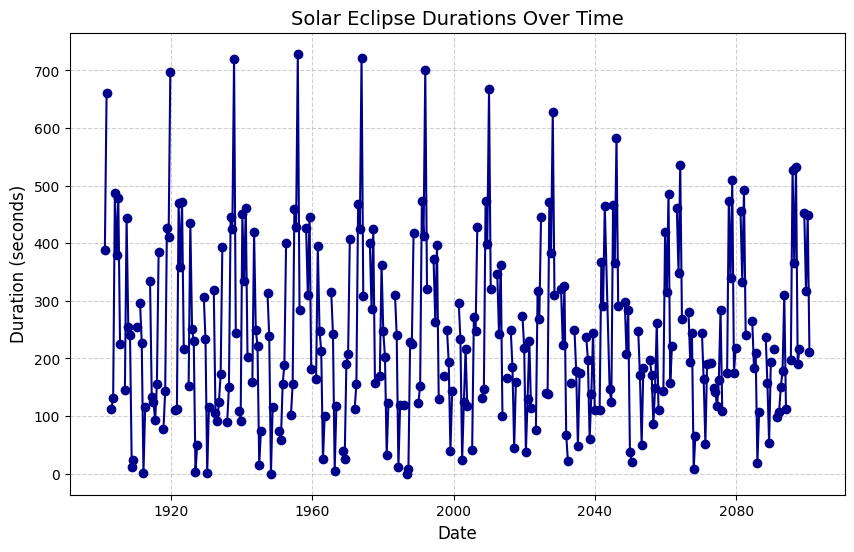

In [6]:
import matplotlib.pyplot as plt

# Create a simple time-series plot of eclipse durations
plt.figure(figsize=(10, 6))

# Plot duration (in seconds) over time
plt.plot(df['date'], df['duration_sec'], color='darkblue', marker='o', linestyle='-', linewidth=1.5)

# Add labels and title for clarity
plt.title('Solar Eclipse Durations Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Duration (seconds)', fontsize=12)

# Improve readability with gridlines
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

## Final Thoughts

This notebook demonstrates a clean, reproducible workflow for analyzing solar eclipse data:
- Data cleaning and transformation
- Statistical summaries
- Chronological filtering
- Visualization for trend discovery

You can extend this analysis by:
- Comparing eclipse durations by region  
- Adding interactive visualizations with Plotly  
- Predicting future eclipse durations using regression models  

This structure ensures clarity, professionalism, and scalability for future data projects.